# Continuous Normalizing Flows 

This notebook implements a self-contained continuous normalizing flow in plain PyTorch on a two-dimensional dataset:
- a time-conditioned vector field $f_\psi(x_t, t)$
- fixed-step Euler integration
- exact 2D divergence from `torch.autograd`


What happens if you implement the CNF _without_ the log-probability calculation? 

Try to implement the CNF sampling integration so that you can use an MSE loss between the target and model sample (obtained by this integration).
- implementing this would mean that the expensive Jacobian calculation (over time) is not necessary
- by using an MSE loss for the flow samples against the data, instead of the likelihood under the model $p_\theta(x)$, what assumption are you making about $p(x)$ in your model $p_\theta(x)$? 

You can also make this model conditional, e.g. to learn the PDF $p(x|y)$ instead of just $p(x)$. Look at the `make_moons_dataset` where the labels $y$ of the datapoints are returned.


In [ ]:
from __future__ import annotations

import math

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons # Try other distributions in the sklearn.datasets package

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


def make_moons_dataset(n_samples: int = 5000, noise: float = 0.08):
    x, y = make_moons(n_samples=n_samples, noise=noise) 
    x = x.astype(np.float32)

    x_mean = x.mean(axis=0, keepdims=True)
    x_std = x.std(axis=0, keepdims=True)
    x = (x - x_mean) / x_std

    return x, x_mean, x_std, y


## Vector Field And CNF

A continuous normalizing flow defines an ODE

$$\frac{dx(t)}{dt} = f_\theta(t, x(t)).$$

Here `f_theta` is the neural network `VectorField`. The model starts from a simple base distribution at time `t0` and flows it to the data distribution at time `t1`.

In this notebook we do not solve the ODE analytically. Instead, we approximate the integral numerically with **Euler steps**. If we split the interval `[t0, t1]` into `n_steps` pieces, then

$$\Delta t = \frac{t_1 - t_0}{\text{n\_steps}}, \qquad x_{k+1} = x_k + \Delta t\, f_\theta(t_k, x_k).$$

So `n_steps` is literally the number of Euler updates used to approximate the continuous flow. Larger `n_steps` gives a more accurate ODE solve, but costs more compute (e.g. the neural network is called at each step).

For likelihood training, we also integrate a log-density correction term involving the divergence of the vector field. That is why the model can evaluate `log_prob(x)`: it solves the ODE backward from the data point to the base distribution, while accumulating the change in the PDF density along the path.


In [2]:
# ============================================================
# Vector field and CNF
# ============================================================


class VectorField(nn.Module):
    def __init__(self, dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, t: torch.Tensor | float, x: torch.Tensor) -> torch.Tensor:
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=x.dtype, device=x.device)
        t = t.to(dtype=x.dtype, device=x.device).reshape(1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t], dim=1))


def exact_divergence(dx: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    div = torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
    for i in range(x.shape[1]):
        grad_i = torch.autograd.grad(
            dx[:, i].sum(),
            x,
            create_graph=True,
            retain_graph=True,
        )[0][:, i]
        div = div + grad_i
    return div


class CNF(nn.Module):
    def __init__(
        self,
        dim: int,
        hidden_dim: int = 64,
        n_steps: int = 32,
        t0: float = 0.0,
        t1: float = 1.0,
    ):
        super().__init__()
        self.dim = dim
        self.n_steps = n_steps
        self.t0 = t0
        self.t1 = t1
        self.field = VectorField(dim, hidden_dim)

    def base_log_prob(self, z: torch.Tensor) -> torch.Tensor:
        return -0.5 * (z**2 + math.log(2 * math.pi)).sum(dim=-1)

    def _flow_and_logp_rates(
        self,
        t: torch.Tensor,
        x: torch.Tensor,
        delta_logp: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        del delta_logp
        x = x.requires_grad_(True)
        velocity = self.field(t, x)
        divergence = exact_divergence(velocity, x)
        # The augmented ODE tracks both the state x(t) and the running
        # log-density correction term.
        d_delta = -divergence.unsqueeze(1)
        return velocity, d_delta

    def _euler_step_state(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
        dt: torch.Tensor,
    ) -> torch.Tensor:
        velocity = self.field(t, x)
        return x + dt * velocity

    def _euler_step_augmented(
        self,
        x: torch.Tensor,
        delta_logp: torch.Tensor,
        t: torch.Tensor,
        dt: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        velocity, d_delta = self._flow_and_logp_rates(t, x, delta_logp)
        x = x + dt * velocity
        delta_logp = delta_logp + dt * d_delta
        return x, delta_logp

    def integrate_state(
        self,
        x0: torch.Tensor,
        t0: float,
        t1: float,
        steps: int | None = None,
    ) -> torch.Tensor:
        steps = self.n_steps if steps is None else steps
        x = x0
        t = torch.tensor(t0, device=x.device, dtype=x.dtype)
        dt = torch.tensor((t1 - t0) / steps, device=x.device, dtype=x.dtype)

        for _ in range(steps):
            # Euler solve of dx/dt = f_theta(t, x)
            x = self._euler_step_state(x, t, dt)
            t = t + dt
        return x

    def integrate_backward_density(
        self,
        x1: torch.Tensor,
        steps: int | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        steps = self.n_steps if steps is None else steps
        x = x1
        delta_logp = torch.zeros(x.shape[0], 1, device=x.device, dtype=x.dtype)
        t = torch.tensor(self.t1, device=x.device, dtype=x.dtype)
        dt = torch.tensor((self.t0 - self.t1) / steps, device=x.device, dtype=x.dtype)

        for _ in range(steps):
            # Backward Euler solve for the augmented state used in likelihood computation.
            x, delta_logp = self._euler_step_augmented(x, delta_logp, t, dt)
            t = t + dt
        return x, delta_logp.squeeze(1)

    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
        z, delta_logp = self.integrate_backward_density(x)
        return self.base_log_prob(z) - delta_logp

    def log_prob_batched(self, x: torch.Tensor, batch_size: int = 2048) -> torch.Tensor:
        outputs = []
        for start in range(0, x.shape[0], batch_size):
            x_batch = x[start : start + batch_size]
            outputs.append(self.log_prob(x_batch))
        return torch.cat(outputs, dim=0)

    @torch.no_grad()
    def sample(self, n: int, device: torch.device) -> torch.Tensor:
        z = torch.randn(n, self.dim, device=device)
        return self.integrate_state(z, t0=self.t0, t1=self.t1)

    @torch.no_grad()
    def sample_trajectory(self, n: int, device: torch.device) -> list[np.ndarray]:
        z = torch.randn(n, self.dim, device=device)
        x = z
        states = [x.detach().cpu().numpy().copy()]

        t = torch.tensor(self.t0, device=device, dtype=z.dtype)
        dt = torch.tensor((self.t1 - self.t0) / self.n_steps, device=device, dtype=z.dtype)
        for _ in range(self.n_steps):
            x = self._euler_step_state(x, t, dt)
            states.append(x.detach().cpu().numpy().copy())
            t = t + dt
        return states


## Training

We maximize likelihood on the standardized `make_moons` dataset.

The important conceptual point is that the loss is **not** computed from a single feed-forward pass. To evaluate `log_prob(x)`, the CNF solves the ODE backward in time over `n_steps` Euler updates and accumulates the density change along that trajectory. Training therefore learns the vector field through the numerical ODE solve itself.


In [3]:
# ============================================================
# Training
# ============================================================


def train_cnf(
    model: CNF,
    dataloader: DataLoader,
    optimizer: optim.Optimizer,
    device: torch.device,
    epochs: int = 250,
) -> list[float]:
    model.train()
    losses = []

    for epoch in range(epochs):
        running_loss = 0.0
        n_total = 0

        for (x_batch,) in dataloader:
            x_batch = x_batch.to(device)

            loss = -model.log_prob(x_batch).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)
            n_total += x_batch.size(0)

        epoch_loss = running_loss / n_total
        losses.append(epoch_loss)

        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:4d} | NLL {epoch_loss:.4f}")

    return losses


## Visualization

These helpers show the training data, learned density, generated samples, and sample trajectories under the learned flow.


In [4]:
# ============================================================
# Visualization
# ============================================================


def plot_results(
    model: CNF,
    data_np: np.ndarray,
    losses: list[float],
    device: torch.device,
) -> None:
    model.eval()

    with torch.no_grad():
        samples = model.sample(2000, device=device).cpu().numpy()

    x_min = min(data_np[:, 0].min(), samples[:, 0].min()) - 0.5
    x_max = max(data_np[:, 0].max(), samples[:, 0].max()) + 0.5
    y_min = min(data_np[:, 1].min(), samples[:, 1].min()) - 0.5
    y_max = max(data_np[:, 1].max(), samples[:, 1].max()) + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 220),
        np.linspace(y_min, y_max, 220),
    )
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    grid_tensor = torch.from_numpy(grid).to(device)
    logp = model.log_prob_batched(grid_tensor, batch_size=2048).detach().cpu().numpy()
    p = np.exp(logp).reshape(xx.shape)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].scatter(data_np[:, 0], data_np[:, 1], s=8, alpha=0.5)
    axes[0].set_title("Training data")

    cf = axes[1].contourf(xx, yy, p, levels=40)
    axes[1].scatter(data_np[:, 0], data_np[:, 1], s=3, c="white", alpha=0.2)
    axes[1].set_title("Learned density")
    plt.colorbar(cf, ax=axes[1])

    axes[2].scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.5)
    axes[2].set_title("Samples from trained CNF")

    for ax in axes:
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Negative log-likelihood")
    plt.title("Training curve")
    plt.tight_layout()
    plt.show()


def plot_sample_trajectories(model: CNF, data_np: np.ndarray, device: torch.device) -> None:
    model.eval()
    states = model.sample_trajectory(128, device=device)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(data_np[:, 0], data_np[:, 1], s=8, alpha=0.15, color="black", label="training data")

    for i in range(min(32, states[0].shape[0])):
        traj = np.stack([state[i] for state in states], axis=0)
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.35, linewidth=1.0, color="firebrick")

    ax.scatter(states[0][:, 0], states[0][:, 1], s=8, alpha=0.3, color="royalblue", label="base samples")
    ax.scatter(states[-1][:, 0], states[-1][:, 1], s=8, alpha=0.5, color="firebrick", label="final samples")
    ax.set_title("CNF sample trajectories")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


## Run The Example

Execute the next cell to train the CNF and plot results.


Using device: cpu
Epoch    1 | NLL 2.7360
Epoch   25 | NLL 1.8330
Epoch   50 | NLL 1.6658
Epoch   75 | NLL 1.6281
Epoch  100 | NLL 1.6033


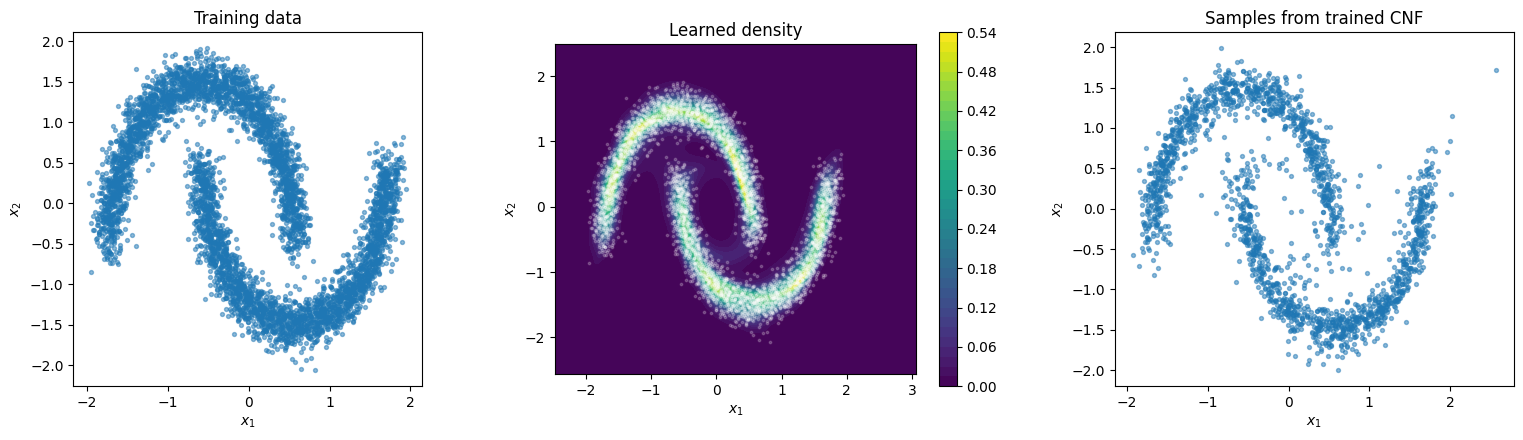

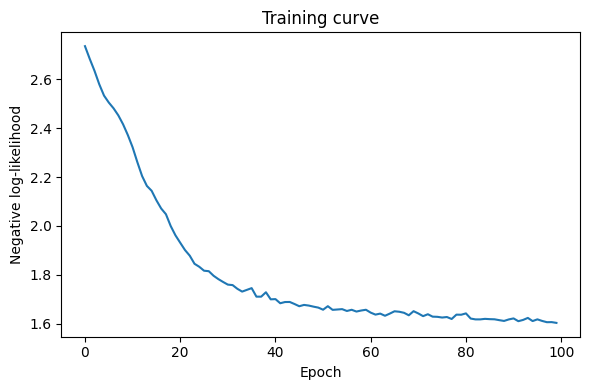

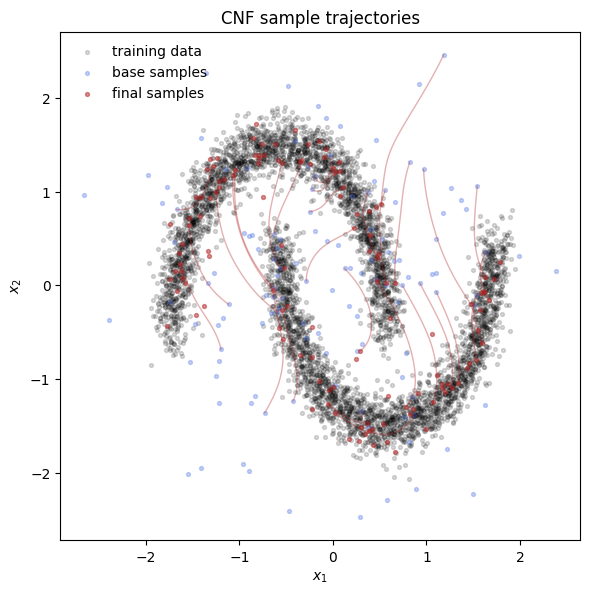

In [ ]:
# ============================================================
# Main
# ============================================================


def main() -> None:

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    x_np, _, _, y_np = make_moons_dataset(n_samples=5000, noise=0.08)
    x_tensor = torch.from_numpy(x_np)
    y_tensor = torch.from_numpy(y_np)
    dataset = TensorDataset(x_tensor)
    dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

    model = CNF(dim=2, hidden_dim=64, n_steps=32).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

    losses = train_cnf(
        model=model,
        dataloader=dataloader,
        optimizer=optimizer,
        device=device,
        epochs=100,
    )

    plot_results(model, x_np, losses, device)
    plot_sample_trajectories(model, x_np, device)


main()
